Part 8: Deep Neural Network Comparison (YOLO)
Compares our background subtraction detector against YOLO pretrained on COCO.

In [1]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ultralytics import YOLO
import time

frames_path = Path("../frames/View_001/")
n_frames = 795
confidence_threshold = 0.5

In [2]:
def detect_pedestrians_yolo(image, conf_threshold=0.5):
    """
    Run YOLO detection on an image and return pedestrian bounding boxes.

    Returns:
        List of bounding boxes: [x1, y1, x2, y2, confidence]
    """
    results = model(image, verbose=False)  # verbose=False to avoid printing

    detections = []
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                cls_id = int(box.cls[0])
                if cls_id == PERSON_CLASS_ID:
                    conf = float(box.conf[0])
                    if conf >= conf_threshold:
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        detections.append([x1, y1, x2, y2, conf])
    return detections

print("Loading YOLO26n pretrained model...")
model = YOLO("yolo26n.pt") # Pretrained on COCO
PERSON_CLASS_ID = 0
print("Model loaded successfully!")

Loading YOLO26n pretrained model...
Model loaded successfully!


In [3]:
yolo_detections_by_frame = {}
frame_indices = []

print(f"Processing frames with YOLO...")
start_time = time.time()

for f in range(0, n_frames):
    frame_file = frames_path / f"frame_{f:04d}.jpg"
    if not frame_file.exists():
        continue
    
    # Read image
    img = cv2.imread(str(frame_file))
    if img is None:
        continue
    
    # Run detection
    detections = detect_pedestrians_yolo(img, confidence_threshold)
    yolo_detections_by_frame[f] = detections
    frame_indices.append(f)
    
    # Progress indicator
    if len(frame_indices) % 50 == 0:
        print(f"  Processed {len(frame_indices)} frames...")

elapsed = time.time() - start_time
print(f"Completed! Processed {len(frame_indices)} frames in {elapsed:.1f} seconds")
print(f"Average {elapsed/len(frame_indices):.2f} seconds per frame")

Processing frames with YOLO...


/home/book/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


  Processed 50 frames...
  Processed 100 frames...
  Processed 150 frames...
  Processed 200 frames...
  Processed 250 frames...
  Processed 300 frames...
  Processed 350 frames...
  Processed 400 frames...
  Processed 450 frames...
  Processed 500 frames...
  Processed 550 frames...
  Processed 600 frames...
  Processed 650 frames...
  Processed 700 frames...
  Processed 750 frames...
Completed! Processed 795 frames in 29.0 seconds
Average 0.04 seconds per frame


In [ ]:
import scipy.io as sio
import os

# Our detections from Part 2 (saved as our_detections.txt)
det_file = Path("../data/our_detections.txt")
gt_file = Path("../data/gt/gt.txt")

our_detections_by_frame = {}
gt_by_frame = {}

if os.path.exists(det_file):
    # Format: [frame, id, left, top, width, height, conf, x, y, z]
    our_data = np.loadtxt(det_file, delimiter=',')
    
    for row in our_data:
        f = int(row[0])  # frame number (0-based in file)
        left, top, width, height = row[2], row[3], row[4], row[5]
        # Convert to [x1, y1, x2, y2] format
        x1, y1, x2, y2 = left, top, left + width, top + height
        conf = row[6]
        
        if f not in our_detections_by_frame:
            our_detections_by_frame[f] = []
        our_detections_by_frame[f].append([x1, y1, x2, y2, conf])
    
    print(f"Loaded our detector results from {det_file}")
    print(f"  Total detections: {len(our_data)}")
    print(f"  Frames with detections: {len(our_detections_by_frame)}")
else:
    print(f"Warning: {det_file} not found. Run Part 2 first.")
    our_detections_by_frame = {}
print()

if os.path.exists(gt_file):
    gt_data = np.loadtxt(gt_file, delimiter=',')
    # Format: [frame, id, left, top, width, height, conf, x, y, z]
    for row in gt_data:
        f = int(row[0])  # frame number (0-based)
        left, top, width, height = row[2], row[3], row[4], row[5]
        # Convert to [x1, y1, x2, y2]
        x1, y1, x2, y2 = left, top, left + width, top + height
        person_id = int(row[1])
        
        if f not in gt_by_frame:
            gt_by_frame[f] = []
        gt_by_frame[f].append([x1, y1, x2, y2, person_id])
    
    print(f"Loaded ground truth from {gt_file}")
    print(f"  Total annotations: {len(gt_data)}")
    print(f"  Frames with GT: {len(gt_by_frame)}")
else:
    print(f"Error: {gt_file} not found")
    gt_by_frame = {}

common_frames = set(yolo_detections_by_frame.keys()) & set(our_detections_by_frame.keys()) & set(gt_by_frame.keys())
common_frames = sorted(common_frames)

gt_counts = [len(gt_by_frame[f]) for f in common_frames]
yolo_counts = [len(yolo_detections_by_frame[f]) for f in common_frames]
our_counts = [len(our_detections_by_frame[f]) for f in common_frames]

Loaded our detector results from ../data/our_detections.txt
  Total detections: 3744
  Frames with detections: 795

Loaded ground truth from ../data/gt/gt.txt
  Total annotations: 4650
  Frames with GT: 795


FRAME-BASED IoU WITH GROUND TRUTH - PERFORMANCE COMPARISON
Frames analyzed: 794

YOLO:
  Frames with any detection overlap: 794 (100.0%)
  Mean best IoU per frame: 0.841
  Median best IoU per frame: 0.850
  Frames with IoU > 0.5: 793 (99.9%)

Our Detector:
  Frames with any detection overlap: 794 (100.0%)
  Mean best IoU per frame: 0.800
  Median best IoU per frame: 0.816
  Frames with IoU > 0.5: 776 (97.7%)


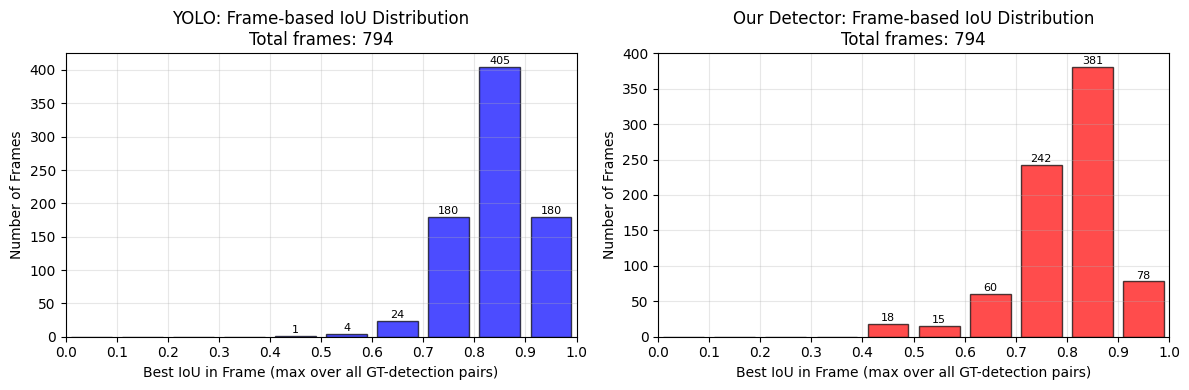

In [5]:
def compute_iou(box1, box2):
    """Compute IoU between two boxes [x1,y1,x2,y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def compute_frame_best_iou(gt_boxes, det_boxes):
    """
    For a single frame, compute the best IoU achievable.
    Returns the maximum IoU over all GT-detection pairs.
    """
    if len(gt_boxes) == 0 or len(det_boxes) == 0:
        return 0.0
    
    best_iou = 0.0
    for gt in gt_boxes:
        for det in det_boxes:
            iou_val = compute_iou(gt[:4], det[:4])
            if iou_val > best_iou:
                best_iou = iou_val
    
    return best_iou

# Evaluate both methods against ground truth – frame-based
yolo_frame_ious = []
our_frame_ious = []

for f in common_frames:
    gt_boxes = gt_by_frame[f]
    yolo_boxes = yolo_detections_by_frame[f]
    our_boxes = our_detections_by_frame[f]
    
    # Best IoU for YOLO in this frame
    yolo_best = compute_frame_best_iou(gt_boxes, yolo_boxes)
    yolo_frame_ious.append(yolo_best)
    
    # Best IoU for Our detector in this frame
    our_best = compute_frame_best_iou(gt_boxes, our_boxes)
    our_frame_ious.append(our_best)

# Convert to numpy arrays for easier analysis
yolo_frame_ious = np.array(yolo_frame_ious)
our_frame_ious = np.array(our_frame_ious)

# Calculate statistics
print("=" * 60)
print("FRAME-BASED IoU WITH GROUND TRUTH - PERFORMANCE COMPARISON")
print("=" * 60)
print(f"Frames analyzed: {len(common_frames)}")
print(f"\nYOLO:")
print(f"  Frames with any detection overlap: {np.sum(yolo_frame_ious > 0)} ({100*np.mean(yolo_frame_ious > 0):.1f}%)")
print(f"  Mean best IoU per frame: {np.mean(yolo_frame_ious):.3f}")
print(f"  Median best IoU per frame: {np.median(yolo_frame_ious):.3f}")
print(f"  Frames with IoU > 0.5: {np.sum(yolo_frame_ious > 0.5)} ({100*np.mean(yolo_frame_ious > 0.5):.1f}%)")
print(f"\nOur Detector:")
print(f"  Frames with any detection overlap: {np.sum(our_frame_ious > 0)} ({100*np.mean(our_frame_ious > 0):.1f}%)")
print(f"  Mean best IoU per frame: {np.mean(our_frame_ious):.3f}")
print(f"  Median best IoU per frame: {np.median(our_frame_ious):.3f}")
print(f"  Frames with IoU > 0.5: {np.sum(our_frame_ious > 0.5)} ({100*np.mean(our_frame_ious > 0.5):.1f}%)")

# Plot histogram by frame (not by detection)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Define bins 0-1 in steps of 0.1
bins = np.arange(0, 1.1, 0.1)

# YOLO histogram (by frame)
counts_yolo, edges = np.histogram(yolo_frame_ious, bins=bins)
centers = edges[:-1] + 0.05
axes[0].bar(centers, counts_yolo, width=0.08, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Best IoU in Frame (max over all GT-detection pairs)')
axes[0].set_ylabel('Number of Frames')
axes[0].set_title(f'YOLO: Frame-based IoU Distribution\nTotal frames: {len(common_frames)}')
axes[0].set_xlim([0, 1])
axes[0].set_xticks(np.arange(0, 1.1, 0.1))
axes[0].grid(True, alpha=0.3)

# Add value labels
for i, count in enumerate(counts_yolo):
    if count > 0:
        axes[0].text(centers[i], count + 1, str(count), 
                    ha='center', va='bottom', fontsize=8)

# Our detector histogram (by frame)
counts_our, _ = np.histogram(our_frame_ious, bins=bins)
axes[1].bar(centers, counts_our, width=0.08, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Best IoU in Frame (max over all GT-detection pairs)')
axes[1].set_ylabel('Number of Frames')
axes[1].set_title(f'Our Detector: Frame-based IoU Distribution\nTotal frames: {len(common_frames)}')
axes[1].set_xlim([0, 1])
axes[1].set_xticks(np.arange(0, 1.1, 0.1))
axes[1].grid(True, alpha=0.3)

for i, count in enumerate(counts_our):
    if count > 0:
        axes[1].text(centers[i], count + 1, str(count), 
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

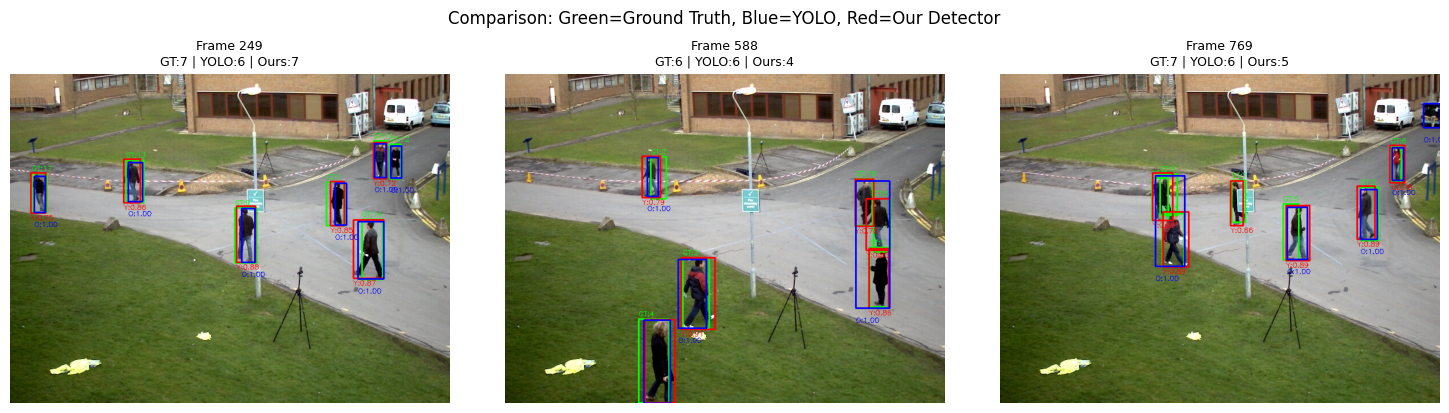

In [6]:
def draw_all_detections(image, gt_boxes, yolo_boxes, our_boxes):
    """Draw all three on the same image with different colors"""
    img_copy = image.copy()
    
    # Draw Ground Truth (green)
    for i, gt in enumerate(gt_boxes):
        x1, y1, x2, y2, pid = gt
        cv2.rectangle(img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(img_copy, f"GT:{pid}", (int(x1), int(y1)-5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
    
    # Draw YOLO detections (blue)
    for i, yolo in enumerate(yolo_boxes):
        x1, y1, x2, y2, conf = yolo
        cv2.rectangle(img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
        cv2.putText(img_copy, f"Y:{conf:.2f}", (int(x1), int(y2)+12), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    
    # Draw Our detections (red)
    for i, our in enumerate(our_boxes):
        x1, y1, x2, y2, conf = our
        cv2.rectangle(img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
        cv2.putText(img_copy, f"O:{conf:.2f}", (int(x1), int(y2)+25), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
    
    return img_copy

# Select frames with various scenarios
frames_to_show = [249, 588, 769]
for f in common_frames:
    if len(gt_by_frame[f]) > 0 and len(yolo_detections_by_frame[f]) > 0:
        frames_to_show.append(f)
    if len(frames_to_show) >= 6:
        break

# Ensure we have good spread
frames_to_show = frames_to_show[:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for idx, f in enumerate(frames_to_show):
    # Load original frame
    img_path = frames_path / f"frame_{f:04d}.jpg"
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get all annotations
    gt_boxes = gt_by_frame.get(f, [])
    yolo_boxes = yolo_detections_by_frame.get(f, [])
    our_boxes = our_detections_by_frame.get(f, [])
    
    # Draw everything
    img_with_all = draw_all_detections(img_rgb, gt_boxes, yolo_boxes, our_boxes)
    
    axes[idx].imshow(img_with_all)
    axes[idx].set_title(f"Frame {f}\nGT:{len(gt_boxes)} | YOLO:{len(yolo_boxes)} | Ours:{len(our_boxes)}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Comparison: Green=Ground Truth, Blue=YOLO, Red=Our Detector', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
